In [1]:
import pandas as pd
import sqlite3

def dados_bancos():
    conn = sqlite3.connect('dados/banking.db')

    financial_indicators = ['ano', 'cnpj', 'NOME_INSTITUICAO', 'TAXONOMIA', 'CONTA', 'NOME_CONTA', 'saldo_medio']

    query = f"""
    SELECT 
        {', '.join(financial_indicators)} 
    FROM    
        balancetes_media_ano
    WHERE 
        cnpj IN (
            SELECT cnpj
            FROM balancetes_media_ano
            GROUP BY ano, cnpj
        );"""

    df = pd.read_sql_query(query, conn)

    conn.close()

    df = df.rename(columns={'NOME_INSTITUICAO': 'nome', 'TAXONOMIA': 'taxonomia', 'CONTA': 'conta', 'NOME_CONTA': 'nome_conta', 'saldo_medio': 'saldo'})

    colunas_para_limpar = ['nome_conta', 'taxonomia']

    for col in colunas_para_limpar:
        df[col] = (df[col]
                .str.lower()
                .str.normalize('NFD')
                .str.replace(r'[\u0300-\u036f]', '', regex=True))

    # Padronizando nomes
    df.loc[df['conta'] == 10000007, 'nome_conta'] = "ativo realizavel"
    df.loc[df['conta'] == 16300000, 'nome_conta'] = "financiamentos rurais"
    df.loc[df['conta'] == 16100004, 'nome_conta'] = "emprestimos e direitos creditorios descontados"
    df.loc[df['conta'] == 14100006, 'nome_conta'] = "direitos junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 20000004, 'nome_conta'] = "ativo permanente"
    df.loc[df['conta'] == 19900005, 'nome_conta'] = "despesas pagas antecipadamente"
    df.loc[df['conta'] == 23300000, 'nome_conta'] = "bens arrendados - arrendamento operacional"
    df.loc[df['conta'] == 17900007, 'nome_conta'] = "(-) provisoes para operacoes de arrendamento mercantil"
    df.loc[df['conta'] == 12600003, 'nome_conta'] = "aplicacoes em moedas estrangeiras"
    df.loc[df['conta'] == 30000001, 'nome_conta'] = "compensacao ativa"
    df.loc[df['conta'] == 23200007, 'nome_conta'] = "bens arrendados - arrendamento financeiro"
    df.loc[df['conta'] == 13500009, 'nome_conta'] = "vinculado a aquisicao de acoes de empresas estatais"
    df.loc[df['conta'] == 13000004, 'nome_conta'] = "titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 43500000, 'nome_conta'] = "obrigacoes por titulos e valores mobiliarios no exterior"
    df.loc[df['conta'] == 41600005, 'nome_conta'] = "obrigacoes por depositos especiais e de fundos e programas"
    df.loc[df['conta'] == 40000008, 'nome_conta'] = "passivo exigivel"
    df.loc[df['conta'] == 41800001, 'nome_conta'] = "depositos em moedas estrangeiras"
    df.loc[df['conta'] == 41700008, 'nome_conta'] = "ape - depositos especiais"
    df.loc[df['conta'] == 31400002, 'nome_conta'] = "operacoes de risco nivel c"
    df.loc[df['conta'] == 61900008, 'nome_conta'] = "(-) acoes em tesouraria"
    df.loc[df['conta'] == 43200001, 'nome_conta'] = "recursos  de  letras  imobiliarias,  hipotecarias, de credito e similares"
    df.loc[df['conta'] == 43000005, 'nome_conta'] = "recursos de aceites cambiais, letras imobiliarias e hipotecarias, debentures e similares"
    df.loc[df['conta'] == 44100007, 'nome_conta'] = "obrigacoes junto a participantes de sistema de liquidacao e de arranjo de pagamento"
    df.loc[df['conta'] == 44400006, 'nome_conta'] = "relacoes com correspondentes"
    df.loc[df['conta'] == 46200008, 'nome_conta'] = "emprestimos no pais - outras instituicoes"
    df.loc[df['conta'] == 62600008, 'nome_conta'] = "ape - ajustes de avaliacao patrimonial"
    df.loc[df['conta'] == 90000003, 'nome_conta'] = "compensacao passiva"
    df.loc[df['conta'] == 81500000, 'nome_conta'] = "(-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 62500005, 'nome_conta'] = "ape - reservas de lucros"
    df.loc[df['conta'] == 71500003, 'nome_conta'] = "rendas com titulos e valores mobiliarios e instrumentos financeiros derivativos"
    df.loc[df['conta'] == 70000009, 'nome_conta'] = "resultado credor"
    df.loc[df['conta'] == 62100003, 'nome_conta'] = "ape - recursos de associados poupadores"
    df.loc[df['conta'] == 81200001, 'nome_conta'] = "(-) despesas de obrigacoes por emprestimos e repasses"
    df.loc[df['conta'] == 80000006, 'nome_conta'] = "(-) resultado devedor"
    df.loc[df['conta'] == 49700000, 'nome_conta'] = "operacoes especiais"
    df.loc[df['conta'] == 46400004, 'nome_conta'] = "repasses do pais - instituicoes oficiais"
    df.loc[df['conta'] == 46100005, 'nome_conta'] = "emprestimos no pais - instituicoes oficiais"
    df.loc[df['conta'] == 14500008, 'nome_conta'] = "recursos transferidos para bancos cooperativos, confederacoes ou cooperativas centrais"
    df.loc[df['conta'] == 44500009, 'nome_conta'] = "recursos recebidos de cooperativas filiadas"

    # Conta duplicada
    df = df[df['conta'] != 88000008]
    df = df[df['conta'] != 47100004]
    df = df[df['conta'] != 51100007]
    df = df[df['conta'] != 78100004]
    df = df[df['conta'] != 61000001]

    mapa_contas = (
        df.groupby('conta')['nome_conta']
        .agg(lambda x: x.value_counts().index[0])
        .to_dict()
    )

    novo_mapeamento = {}

    for conta, nome in mapa_contas.items():
        conta_str = str(conta) # Garante que podemos verificar o início
        
        if conta_str.startswith('1'):
            novo_nome = f"ativo realizavel - {nome}"
        elif conta_str.startswith('2'):
            novo_nome = f"ativo permanente - {nome}"
        elif conta_str.startswith('3'):
            novo_nome = f"compensacao ativa - {nome}"
        elif conta_str.startswith('4'):
            novo_nome = f"passivo exigivel - {nome}"
        elif conta_str.startswith('6'):
            novo_nome = f"patrimonio liquido - {nome}"
        elif conta_str.startswith('7'):
            novo_nome = f"resultado credor - {nome}"
        elif conta_str.startswith('8'):
            novo_nome = f"resultado devedor - {nome}"
        elif conta_str.startswith('9'):
            novo_nome = f"compensacao passiva - {nome}"
        else:
            novo_nome = nome # Mantém o original se não houver regra
            
        novo_mapeamento[conta] = novo_nome

    mapa_contas = novo_mapeamento

    df = df.pivot(
        index=['ano', 'cnpj', 'nome', 'taxonomia'],
        columns='conta',
        values='saldo'
    ).reset_index()
    df['ano'] = df['ano'].astype(int)

    # Valor mínimo da conta operações de crédito
    df = df[df[16000001] > 1000000]

    # Excluindo instituições

    # Instituições que não captam depósitos do público (não têm o custo $w_3$ real de mercado) e emprestam dinheiro a taxas subsidiadas pelo governo (TJLP, TLP) para desenvolver regiões, e não para maximizar a margem (NIM).
    df = df[df['taxonomia'] != 'banco nacional de desenvolvimento economico social']
    df = df[df['taxonomia'] != 'bancos de desenvolvimento']
    df = df[df['taxonomia'] != 'agencias de fomento ou de desenvolvimento']

    # As cooperativas de crédito não buscam maximizar o lucro (NIM). Por lei, o objetivo delas é operar no "zero a zero" e devolver o excedente financeiro (as "sobras") aos cooperados. O Índice de Lerner de uma Singular será estruturalmente distorcido, vamos manter apenas os bancos cooperativos.
    df = df[df['taxonomia'] != 'cooperativas de credito']

    # Instituições que não fazem intermediação financeira clássica. O negócio delas é cobrar corretagem/taxas de administração para conectar o cliente à bolsa ou a fundos. A margem financeira de juros (NIM) não é a essência do balanço delas.
    df = df[df['taxonomia'] != 'soc. corretora de titulos e valores mobiliarios']
    df = df[df['taxonomia'] != 'soc distribuidora de titulos e valores mobiliarios']
    df = df[df['taxonomia'] != 'sociedades de credito imobiliario']

    # Instituições que são obrigadas por lei a destinar percentuais engessados de sua captação exclusivamente para o crédito habitacional. Como elas não têm liberdade para pivotar a carteira de crédito para onde dá mais lucro, comparar o spread delas com o de um Banco Múltiplo é injusto e estatisticamente ruidoso.
    df = df[df['taxonomia'] != 'sociedade de credito imobiliario']
    df = df[df['taxonomia'] != 'companhias hipotecarias']
    df = df[df['taxonomia'] != 'associacao de poupanca e emprestimos']

    # Por lei, as SCMs são proibidas de captar depósitos do público. Elas só podem emprestar capital próprio ou dinheiro repassado por outras instituições. Sem a capacidade de captar depósitos, a função de custo translogarítmica falha ao calcular o custo marginal delas.
    df = df[df['taxonomia'] != 'sociedade de credito ao microempreendedor']


    colunas_para_inverter = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia']]
    colunas_invertidas = []
        # Se o maior valor da coluna for 0 ou negativo, significa que toda a coluna é negativa
    for col in colunas_para_inverter:
        # Calcula o máximo e o mínimo ignorando os vazios explicitamente
        max_val = df[col].max(skipna=True)
        min_val = df[col].min(skipna=True)
        
        # REGRAS PARA INVERTER:
        # 1. pd.notna(max_val): Garante que a coluna não é 100% vazia
        # 2. max_val <= 0: Garante que não há números positivos
        # 3. min_val < 0: Garante que há valores negativos reais (ignora colunas só de Zeros/NaNs)
        
        if pd.notna(max_val) and (max_val <= 0) and (min_val < 0):
            df[col] = df[col] * -1
            colunas_invertidas.append(col)

    df.fillna(0, inplace=True)
    df_inicial = df.copy()
    df_original = df.copy()

    df_inicial = df_inicial.rename(columns=novo_mapeamento)

    # Dividindo os valores pelo Ativo Total (39999993)
    colunas_a_dividir = [col for col in df.columns if col not in ['ano', 'cnpj', 'nome', 'taxonomia', 39999993]]
    for col in colunas_a_dividir:
        df[col] = df[col] / df[39999993]
    df.drop(columns=[39999993, 99999995], inplace=True)
    df_filtrado = df.copy()

    df_original = df_original.rename(columns=novo_mapeamento)
    df = df.rename(columns=novo_mapeamento)
    return df_inicial, df, df_original, mapa_contas

df_inicial, df, df_original, mapa_contas = dados_bancos()


In [2]:
# Eliminando colunas esparsas

def eliminar_colunas_esparsas(df, df_original):
    # 1. Calcular a porcentagem de nulos em cada coluna
    #esparsidade = df.isnull().sum() / len(df)
    esparsidade = (df.isnull() | (df == 0)).sum() / len(df)
    # 2. Visualizar quantas colunas cairiam em diferentes cortes (Opcional, mas útil)
    print(f"Colunas com > 10% de nulos: {sum(esparsidade > 0.10)}")
    print(f"Colunas com > 20% de nulos: {sum(esparsidade > 0.20)}")
    print(f"Colunas com > 30% de nulos: {sum(esparsidade > 0.30)}")
    print(f"Colunas com > 40% de nulos: {sum(esparsidade > 0.40)}")
    print(f"Colunas com > 50% de nulos: {sum(esparsidade > 0.50)}")

    # 3. Definir o limiar
    #limiar_corte = 0.30
    limiar_corte = 0.70

    # Identificar colunas a serem removidas
    colunas_para_remover = esparsidade[esparsidade > limiar_corte].index
    colunas_para_remover = [col for col in colunas_para_remover if col not in ['ano', 'cnpj', 'nome']]
    # 4. Criar o novo dataset filtrado
    df_filtrado = df.drop(columns=colunas_para_remover)
    df_original = df_original.drop(columns=colunas_para_remover)

    print(f"\nDimensão original: {df.shape[1]} colunas")
    print(f"Dimensão após corte de esparsidade: {df_filtrado.shape[1]} colunas")
    df_filtrado.fillna(0, inplace=True)
    return df_filtrado, df_original, colunas_para_remover

df_filtrado, df_original, var_esparsas = eliminar_colunas_esparsas(df, df_original)

Colunas com > 10% de nulos: 171
Colunas com > 20% de nulos: 156
Colunas com > 30% de nulos: 147
Colunas com > 40% de nulos: 142
Colunas com > 50% de nulos: 124

Dimensão original: 209 colunas
Dimensão após corte de esparsidade: 120 colunas


In [3]:
# Análise de Correlação para Identificar Variáveis Redundantes
import numpy as np
from sklearn.preprocessing import StandardScaler
import seaborn as sns

def remover_colunas_redundantes(df_filtrado):
    X = df_filtrado.drop(columns=['ano', 'cnpj', 'nome', 'taxonomia'], axis=1)
    # 1. Usar o Valor Absoluto (Não importa se a correlação é +0.95 ou -0.95, ambas são redundantes)
    corr_matrix = X.corr(method='pearson')
    corr_matrix_abs = corr_matrix.abs()

    # 2. Selecionar apenas o triângulo superior da matriz
    # Isso evita checar a correlação A-B e B-A, e evita a diagonal (correlação de 1.0)
    upper = corr_matrix_abs.where(np.triu(np.ones(corr_matrix_abs.shape), k=1).astype(bool))

    # 3. Definir o Limiar de Corte (Threshold)
    # 0.95 é um bom ponto de partida para dados financeiros para definir "quase redundante"
    threshold = 0.95

    # Encontrar colunas que têm correlação > threshold com qualquer outra coluna
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    print(f"\n--- Contas Redundantes a Descartar (Correlação > {threshold}) ---")
    print(f"Número de variáveis sugeridas para remoção: {len(to_drop)}")
    print(to_drop)

    # Eliminando colunas com valores duplicados (perfeitamente correlacionadas)
    df_filtrado.drop(columns=to_drop, inplace=True)
    X.drop(columns=to_drop, inplace=True)

    scaler = StandardScaler()
    #scaler = RobustScaler()
    X.columns = X.columns.astype(str)
    #colunas_id = ['ano', 'cnpj', 'nome', 'taxonomia']
    #df_identificadores = df_filtrado[colunas_id]
    #X = df_filtrado.drop(columns=colunas_id, axis=1)
    X_scaled = scaler.fit_transform(X)
    return X, df_filtrado, to_drop

X, df_filtrado, var_redundantes = remover_colunas_redundantes(df_filtrado)
variaveis = pd.DataFrame({'Contas': [col for col in X.columns]})



--- Contas Redundantes a Descartar (Correlação > 0.95) ---
Número de variáveis sugeridas para remoção: 23
['ativo realizavel - depositos bancarios', 'ativo realizavel - outros valores e bens', 'ativo realizavel - outros valores e bens', 'ativo permanente - participacoes em coligadas e controladas no pais', 'ativo permanente - ativos intangiveis', 'compensacao ativa - titulos e valores mobiliarios', 'receitas de exercicios futuros', 'resultado credor - receitas operacionais', 'resultado devedor - (-) resultado devedor', 'resultado devedor - (-) despesas operacionais', 'resultado devedor - (-) despesas de cambio', 'resultado devedor - (-) despesas com titulos e valores mobiliarios e instrumentos financeiros derivativos', 'resultado devedor - (-) imposto de renda', 'compensacao passiva - compensacao passiva', 'compensacao passiva - coobrigacoes e riscos em garantias prestadas', 'compensacao passiva - titulos e valores mobiliarios', 'compensacao passiva - custodia de valores', 'compensaca

In [4]:
%load_ext rpy2.ipython

In [5]:
%%R 
library(clustrd)

R[write to console]: Loading required package: ggplot2



R[write to console]: Loading required package: grid



  |======================================================================| 100%

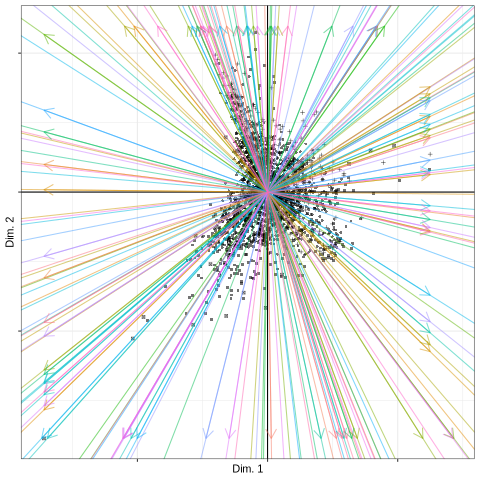

In [6]:
%%R -i X
library(clustrd)

resultado_fkm <- cluspca(data = X, 
                     nclus = 5,         # Número de Clusters
                     ndim = 2,         # Número de Fatores Latentes
                     method = "FKM",
                     nstart = 100)  # Inicializações para evitar ótimos locais 

# Gerar o gráfico
plot(resultado_fkm)

In [7]:
%R -o resultado_fkm

In [19]:
def implementando_clusters(resultado_fkm, df_original, df_filtrado):
    # O rpy2 exporta listas do R como vetores. Podemos converter para um dicionário Python normal
    resultado_dict = dict(resultado_fkm.items())

    # Extraindo o vetor com os números dos clusters (convertendo para um array do numpy)
    clusters_array = np.array(resultado_dict['cluster'])

    # Adicionando a nova coluna com os grupos gerados pelo R!
    df_original['Cluster'] = clusters_array
    df_original.columns = df_original.columns.astype(str)
    coluna_para_mover = df_original.pop('Cluster')
    df_original.insert(4, 'Cluster', coluna_para_mover) 

    df_filtrado['Cluster'] = clusters_array
    df_filtrado.columns = df_filtrado.columns.astype(str)
    coluna_para_mover = df_filtrado.pop('Cluster')
    df_filtrado.insert(4, 'Cluster', coluna_para_mover) 

    # Agora você pode agrupar no Pandas para ver o perfil de cada modelo de negócio:
    df_final = X.copy()
    df_final['Cluster'] = clusters_array
    display(df_final.groupby('Cluster').mean())

    return df_original, df_filtrado, resultado_dict

df_original, df_filtrado, resultado_dict = implementando_clusters(resultado_fkm, df_original, df_filtrado)


conta,ativo realizavel - ativo realizavel,ativo realizavel - disponibilidades,ativo realizavel - caixa,ativo realizavel - reservas livres,ativo realizavel - disponibilidades em moedas estrangeiras,ativo realizavel - aplicacoes interfinanceiras de liquidez,ativo realizavel - aplicacoes em operacoes compromissadas,ativo realizavel - aplicacoes em depositos interfinanceiros,ativo realizavel - titulos e valores mobiliarios e instrumentos financeiros derivativos,ativo realizavel - livres,...,resultado credor - outras receitas nao operacionais,resultado devedor - (-) despesas de captacao,resultado devedor - (-) despesas de obrigacoes por emprestimos e repasses,resultado devedor - (-) despesas administrativas,resultado devedor - (-) aprovisionamentos e ajustes patrimoniais,resultado devedor - (-) outras despesas operacionais,resultado devedor - (-) despesas nao operacionais,resultado devedor - (-) outras despesas nao operacionais,resultado devedor - (-) apuracao de resultado,resultado devedor - (-) participacoes no lucro
Cluster,,,,,,,,,,,,,,,,,,,,,
1,0.279717,0.002701,0.000244,0.000309,0.000685,0.029155,0.016275,0.011169,0.039234,0.029155,...,0.000028,0.004320,0.001096,0.006113,0.004719,0.003015,0.000049,0.000022,-0.001010,0.000048
2,0.172621,0.001410,0.000123,0.000093,0.000739,0.036317,0.022151,0.011824,0.033428,0.019113,...,0.000016,0.002478,0.000756,0.002656,0.001342,0.001061,0.000019,0.000008,-0.000396,0.000031
3,0.376399,0.009247,0.001406,0.000612,0.000467,0.028454,0.015618,0.011437,0.046679,0.041366,...,0.000033,0.006454,0.001244,0.017867,0.016015,0.006266,0.000052,0.000033,-0.001958,0.000061
4,0.410216,0.014997,0.000555,0.001834,0.005281,0.128048,0.083790,0.041478,0.051672,0.030975,...,0.000187,0.003229,0.000922,0.016303,0.002918,0.004201,0.000167,0.000113,-0.001109,0.000058
5,0.521498,0.100650,0.000386,0.015677,0.000002,0.036075,0.014907,0.021121,0.027637,0.022279,...,0.000008,0.002024,0.000445,0.290381,0.019293,0.082578,0.000088,0.000088,-0.001429,0.000011


In [9]:
# Extraindo a matriz de coordenadas dos objetos (bancos)
coordenadas = np.array(resultado_dict['obscoord'])

# Transformando em um DataFrame novinho
df_grafico = pd.DataFrame(
    coordenadas, 
    columns=['Fator_Latente_1', 'Fator_Latente_2'],
    index=X.index # Mantém o nome dos bancos (CNPJ ou Razão Social)
)

# Adicionando a qual cluster eles pertencem para você colorir o gráfico depois
df_grafico['Cluster'] = clusters_array

display(df_grafico.head())

,Fator_Latente_1,Fator_Latente_2,Cluster
0,1.110861,0.807658,1
1,0.027448,2.326672,2
2,2.827993,-0.674264,4
3,1.885367,-1.330518,2
4,2.070720,-1.306886,1


In [20]:
# Extraindo as coordenadas (pesos) das variáveis nos Fatores Latentes
pesos_variaveis = np.array(resultado_fkm['attcoord'])

# Criando o DataFrame para facilitar a leitura
df_pesos = pd.DataFrame(
    pesos_variaveis,
    columns=['Fator_1', 'Fator_2'],
    index=X.columns # O nome das suas variáveis contábeis originais
)

# Visualizando o que mais influencia positiva e negativamente o Fator 1
print("Maior peso no Fator 1:")
display(df_pesos.sort_values(by='Fator_1', ascending=False).head(5))
display(df_pesos.sort_values(by='Fator_1', ascending=True).head(5))

Maior peso no Fator 1:


,Fator_1,Fator_2
conta,,
passivo exigivel - depositos,0.349806,-0.027513
resultado devedor - (-) despesas de captacao,0.270080,-0.062366
passivo exigivel - passivo exigivel,0.266532,0.049258
passivo exigivel - depositos a prazo,0.218979,0.026922
ativo realizavel - ativo realizavel,0.174538,-0.039193


,Fator_1,Fator_2
conta,,
compensacao ativa - operacoes de risco nivel h,-0.206844,-0.166037
ativo realizavel - (-) provisoes para operacoes de credito,-0.204645,-0.186760
compensacao ativa - operacoes de risco nivel f,-0.182236,-0.154771
compensacao ativa - operacoes de risco nivel g,-0.176841,-0.140981
compensacao ativa - compensacao ativa,-0.169491,0.042801


In [ ]:
#df_pesos.to_csv('loadings_fatores.csv', sep=';', index=True)

In [25]:
print(resultado_dict['centroid'])

[[ 0.25197356 -0.61504528]
 [-0.43511554  1.26809351]
 [ 0.03939246 -2.65854296]
 [ 0.89081668  1.44371311]
 [-1.95324001 -2.94646378]]
